In [1]:
# SVM ek trick use karta hai:

# Data ko higher-dimensional space mein represent karo jahan separation easy ho.

In [2]:
# 2D data
#    ↓
# Feature transformation
#    ↓
# Higher-dimensional space
#    ↓
# Linear separation
#    ↓
# Back to original space
#    ↓
# Nonlinear boundary

In [3]:
# Kernel trick ka beauty: SVM ko explicitly har higher-dimensional feature calculate karne ki zarurat nahi hoti. Kernel mathematical shortcut provide karta hai.

In [4]:
# common kernels
# SVC(kernel="linear")
# SVC(kernel="poly")
# SVC(kernel="rbf")
# SVC(kernel="sigmoid")

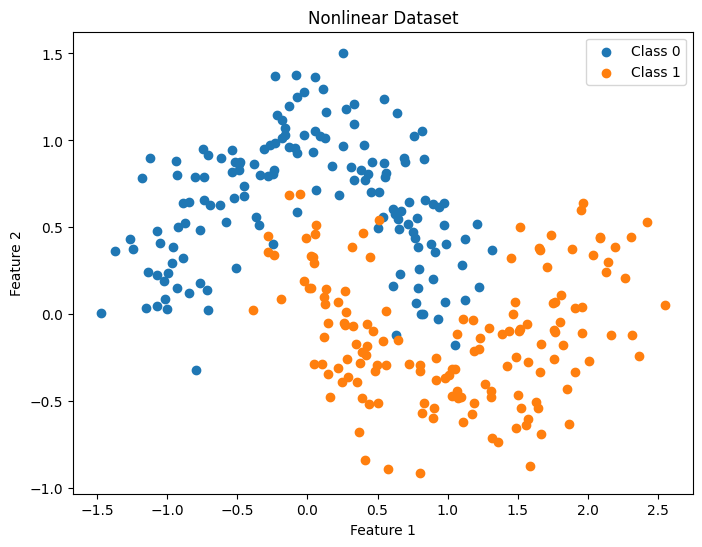

In [5]:
# visualization
import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Nonlinear dataset
X, y = make_moons(
    n_samples=300,
    noise=0.20,
    random_state=42
)

plt.figure(figsize=(8, 6))

plt.scatter(
    X[y == 0, 0],
    X[y == 0, 1],
    label="Class 0"
)

plt.scatter(
    X[y == 1, 0],
    X[y == 1, 1],
    label="Class 1"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Nonlinear Dataset")
plt.legend()
plt.show()

In [6]:
# linear SVM
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

linear_svm = SVC(kernel="linear")

linear_svm.fit(
    X_train_scaled,
    y_train
)

linear_predictions = linear_svm.predict(
    X_test_scaled
)

print(
    "Linear SVM Accuracy:",
    accuracy_score(y_test, linear_predictions)
)

Linear SVM Accuracy: 0.7833333333333333


In [7]:
# RBF svm
rbf_svm = SVC(
    kernel="rbf",
    C=1,
    gamma="scale"
)

rbf_svm.fit(
    X_train_scaled,
    y_train
)

rbf_predictions = rbf_svm.predict(
    X_test_scaled
)

print(
    "RBF SVM Accuracy:",
    accuracy_score(y_test, rbf_predictions)
)

RBF SVM Accuracy: 0.8666666666666667


In [8]:
# visulize both of them
def plot_boundary(model, X_train, y_train, title):

    x_min = X_train[:, 0].min() - 1
    x_max = X_train[:, 0].max() + 1

    y_min = X_train[:, 1].min() - 1
    y_max = X_train[:, 1].max() + 1

    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 400),
        np.linspace(y_min, y_max, 400)
    )

    grid = np.c_[xx.ravel(), yy.ravel()]

    predictions = model.predict(grid)

    predictions = predictions.reshape(xx.shape)

    plt.figure(figsize=(8, 6))

    plt.contourf(
        xx,
        yy,
        predictions,
        alpha=0.25
    )

    plt.scatter(
        X_train[y_train == 0, 0],
        X_train[y_train == 0, 1],
        label="Class 0"
    )

    plt.scatter(
        X_train[y_train == 1, 0],
        X_train[y_train == 1, 1],
        label="Class 1"
    )

    plt.scatter(
        model.support_vectors_[:, 0],
        model.support_vectors_[:, 1],
        s=100,
        facecolors="none",
        edgecolors="black",
        label="Support Vectors"
    )

    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.title(title)
    plt.legend()
    plt.show()

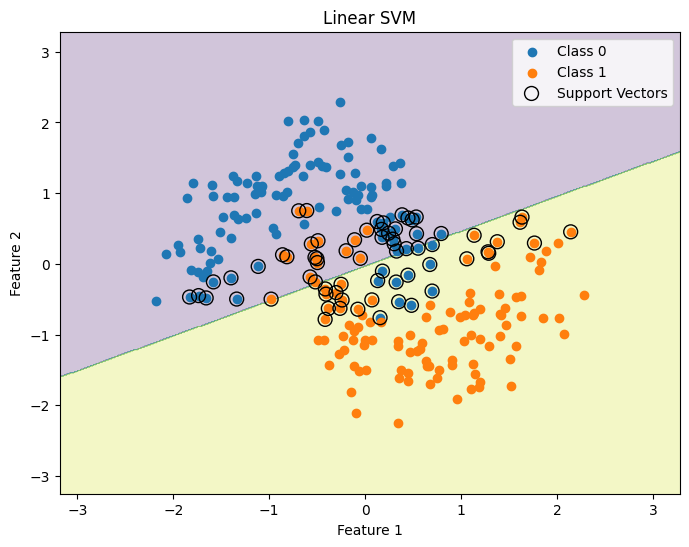

In [9]:
plot_boundary(
    linear_svm,
    X_train_scaled,
    y_train,
    "Linear SVM"
)

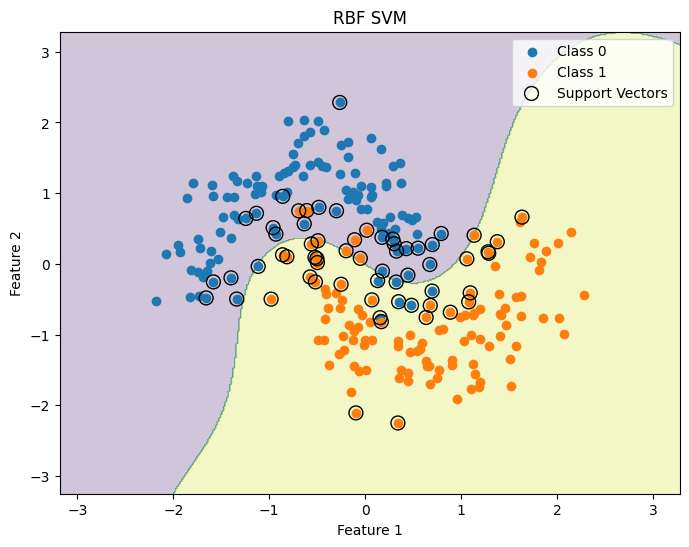

In [10]:
plot_boundary(
    rbf_svm,
    X_train_scaled,
    y_train,
    "RBF SVM"
)

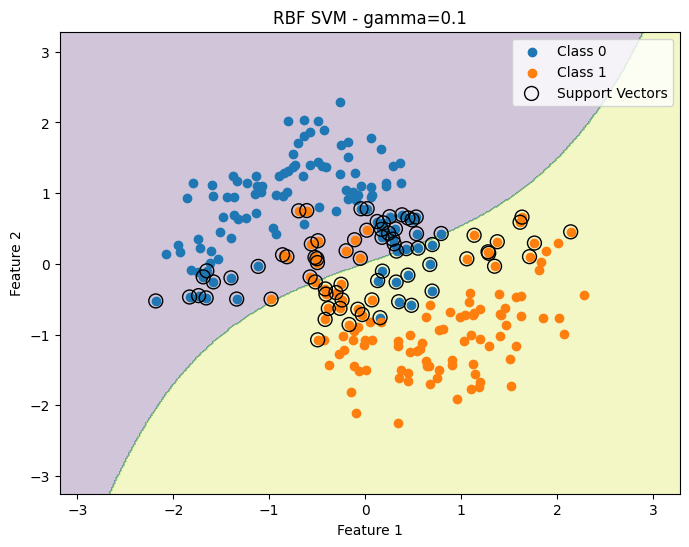

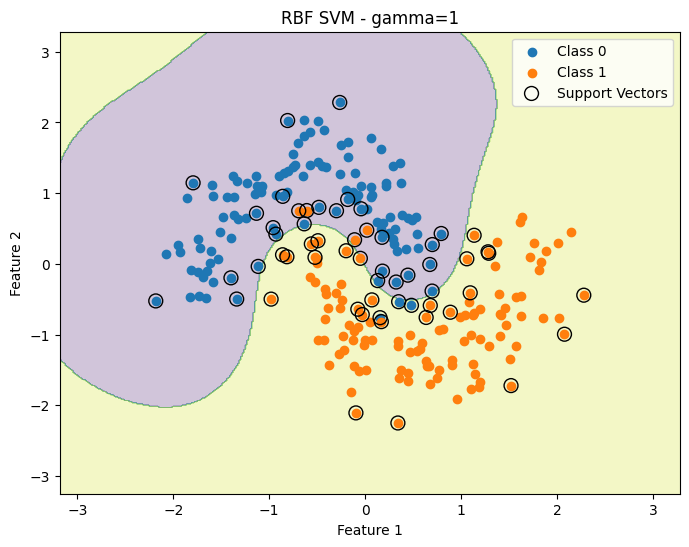

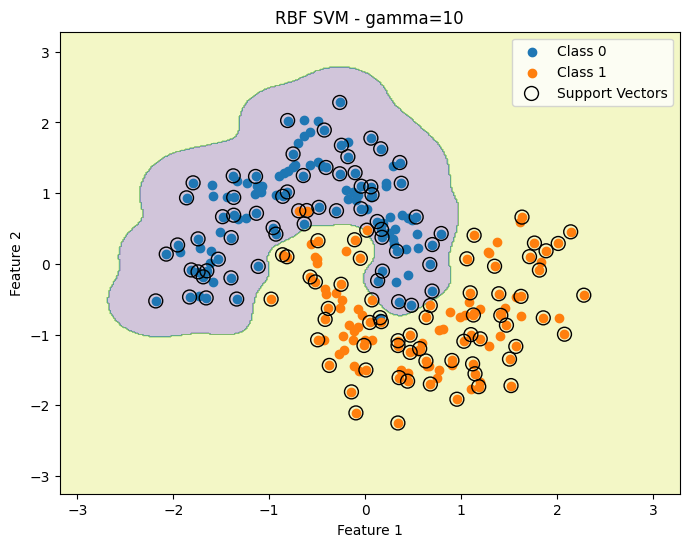

In [11]:
# visually see gamma with diff values
for gamma_value in [0.1, 1, 10]:

    model = SVC(
        kernel="rbf",
        C=1,
        gamma=gamma_value
    )

    model.fit(
        X_train_scaled,
        y_train
    )

    plot_boundary(
        model,
        X_train_scaled,
        y_train,
        f"RBF SVM - gamma={gamma_value}"
    )

In [12]:
# C aur Gamma ko confuse mat karna

# Ye bohot common interview/viva question hai.

# C

# Controls:

# Training mistakes ko kitna tolerate karna hai?

# Small C → more tolerance
# Large C → less tolerance
# Gamma

# RBF mein controls:

# Ek point ka influence kitni door tak hai?

# Small gamma → wide influence
# Large gamma → narrow/local influence

# So:

# C      → How strict?
# Gamma  → How local?

# Ye line yaad rakhna.

In [13]:
# polynomial kernel
poly_svm = SVC(
    kernel="poly",
    degree=3,
    C=1
)

poly_svm.fit(
    X_train_scaled,
    y_train
)

print(
    "Polynomial SVM Accuracy:",
    poly_svm.score(X_test_scaled, y_test)
)

Polynomial SVM Accuracy: 0.8166666666666667


In [14]:
# SVM optimization aur distance-like kernel behavior feature scales se affected ho sakta hai.

In [15]:
# Data
#  ↓
# Scale features
#  ↓
# Choose kernel
#  ↓
# Find optimal boundary
#  ↓
# Maximize margin
#  ↓
# Support vectors define important part
#  ↓
# Predict new data

In [ ]:
# SVM kab use karna hai?

# Linear SVM:

# Jab classes approximately linearly separable hon.

# RBF SVM:

# Jab nonlinear patterns hon aur dataset small/medium size ka ho.

# Polynomial SVM:

# Jab polynomial-type relationships useful hon.

# Avoid / carefully consider:
# Millions of training examples
# Very large-scale datasets
# Poorly scaled features
# Extremely noisy/high-dimensional data without preprocessing